In [1]:
import tools

In [2]:
vol1 = tools.ext.nib.load("../../../sub-1/ses-1/anat/sub-1_ses-1_T2w.nii.gz")

In [3]:
A1 = vol1.get_fdata()
aff1 = vol1.affine

In [4]:
tools.ext.reload(tools)

<module 'tools' from '/home/becqg/data/2024Phantom3D/derivatives/1-validate-orientations/code/tools.py'>

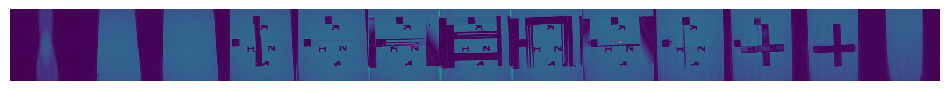

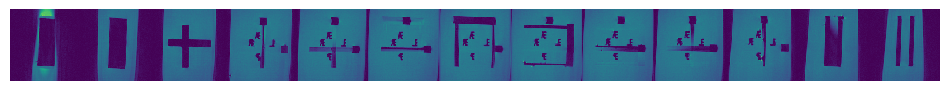

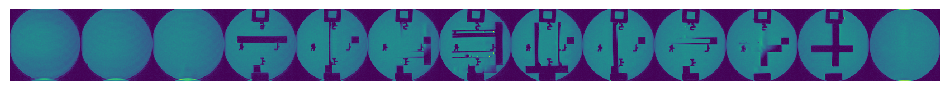

In [5]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1, mode, 10); 

In [6]:
aff1

array([[ -0.390625  ,   0.        ,   0.        ,  23.        ],
       [  0.        ,   0.        ,   0.391     , -27.82850075],
       [  0.        ,   0.390625  ,   0.        , -24.        ],
       [  0.        ,   0.        ,   0.        ,   1.        ]])

In [7]:
import time

In [8]:
A1.dtype

dtype('float64')

In [9]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1, (0.391, 0.391, 0.391), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2-t1)

32.52763080596924


In [10]:
A2.shape

(41, 41, 41)

In [11]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

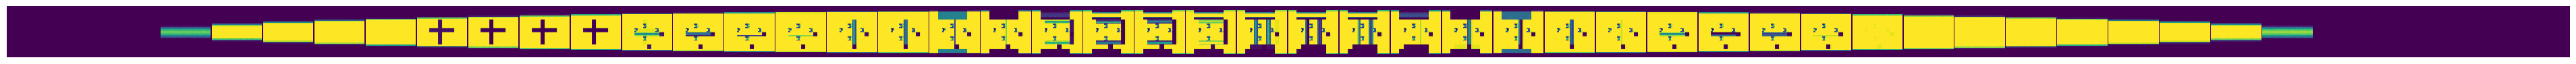

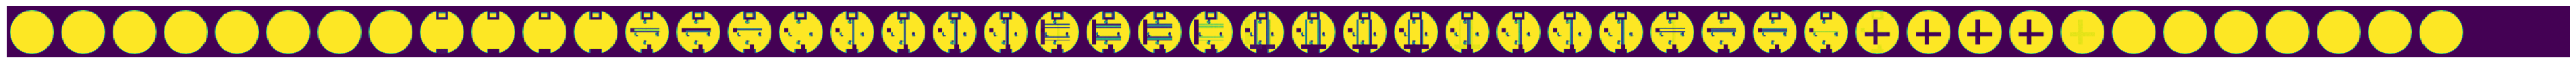

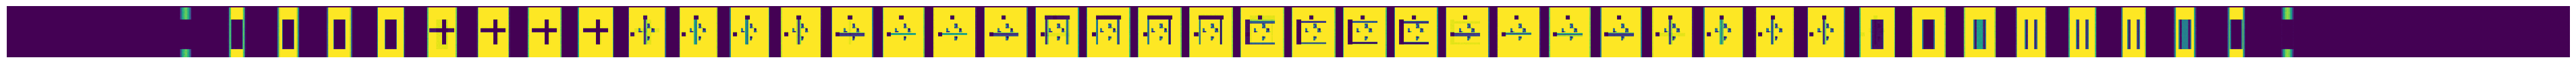

In [12]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [13]:
A0.shape

(49, 49, 49)

In [14]:
A0r = A0[5:-5, 5:-5, 5:-5]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(39, 39, 39)


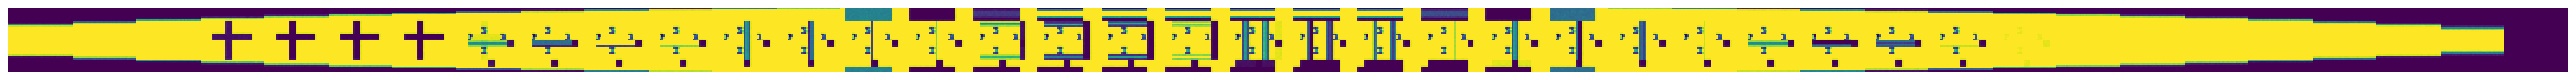

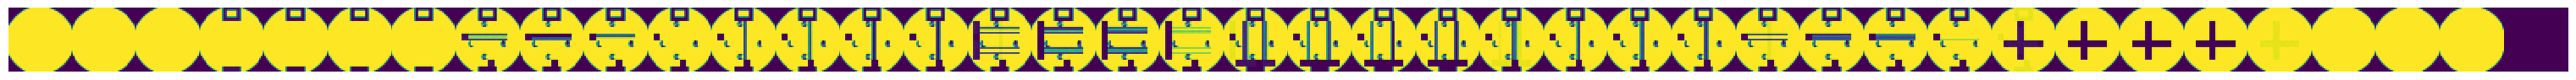

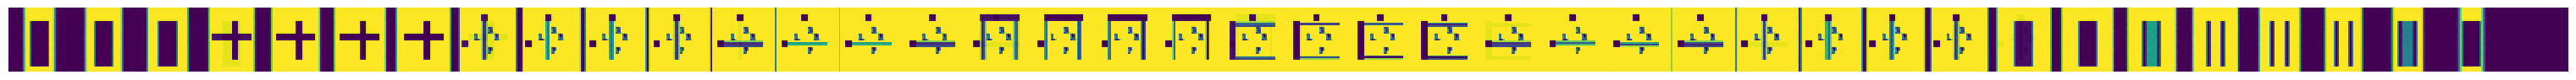

In [15]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode); 

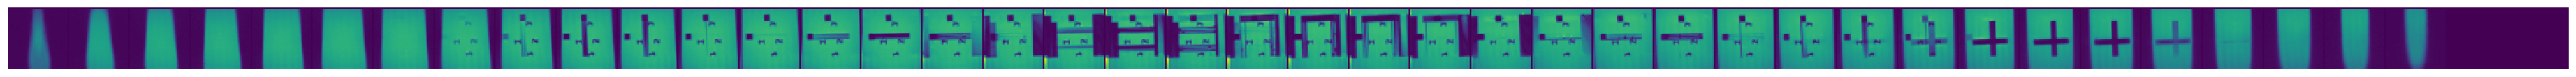

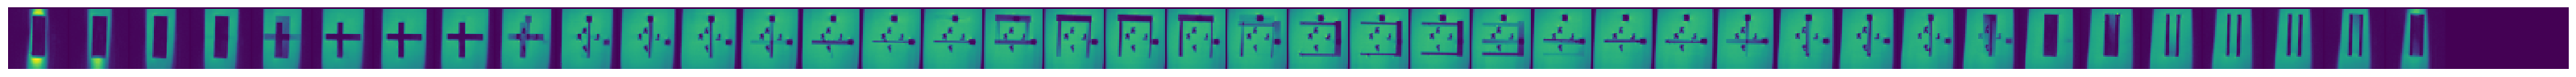

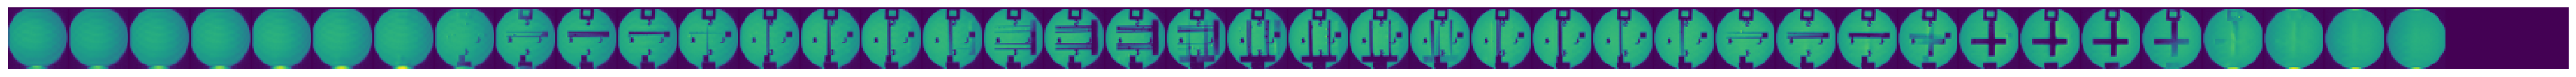

In [16]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode); 

In [17]:
res = {}
t1 = time.time()
A2c = tools.ext.np.clip(A2, 0, 10)
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2c)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

0.3171346187591553


In [18]:
df3

,i,j,k,c
"False_True_True_(1, 0, 2)",1.0,1.0,2.0,0.834642
"False_False_True_(0, 1, 2)",1.0,1.0,2.0,0.834749
"True_False_True_(0, 1, 2)",0.0,1.0,2.0,0.836464
"True_True_True_(1, 0, 2)",1.0,1.0,0.0,0.837318
"True_True_True_(0, 1, 2)",0.0,1.0,0.0,0.839841
"False_True_True_(0, 1, 2)",1.0,1.0,0.0,0.839890
"False_True_True_(2, 1, 0)",0.0,1.0,0.0,0.839926
"False_True_False_(1, 0, 2)",1.0,1.0,2.0,0.840006
"False_False_False_(0, 1, 2)",1.0,1.0,2.0,0.840155
"False_False_True_(1, 0, 2)",1.0,1.0,2.0,0.840177


In [19]:
aff1

array([[ -0.390625  ,   0.        ,   0.        ,  23.        ],
       [  0.        ,   0.        ,   0.391     , -27.82850075],
       [  0.        ,   0.390625  ,   0.        , -24.        ],
       [  0.        ,   0.        ,   0.        ,   1.        ]])

In [20]:
tools.ext.reload(tools)

<module 'tools' from '/home/becqg/data/2024Phantom3D/derivatives/1-validate-orientations/code/tools.py'>

In [21]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)

In [22]:
(flips2, orientations2) = ([True, False, False], [0, 2, 1])

In [23]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'......'